In [2]:
import os
import sys 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras

2025-10-14 19:22:34.666841: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
model = tf.keras.models.load_model('../../Task_3_ML_Models/Dion_Experimentation/model/model.keras')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,848 (1.35 MB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 236,566 (924.09 KB)

In [6]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_test = x_test.astype("float32") / 255.0

print(x_test.shape)
print(y_test.shape)

(10000, 28, 28)
(10000,)


In [7]:
y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [8]:
loss, accuracty = model.evaluate(x_test, y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracty}")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9612 - loss: 0.2114
Loss: 0.21135827898979187
Accuracy: 0.9611999988555908
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.95      0.99      0.97      1135
           2       0.99      0.92      0.95      1032
           3       0.94      0.98      0.96      1010
           4       0.96      0.95      0.96       982
           5       0.98      0.92      0.95       892
           6       0.98      0.97      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.92      0.97      0.94       974
           9       0.97      0.94      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



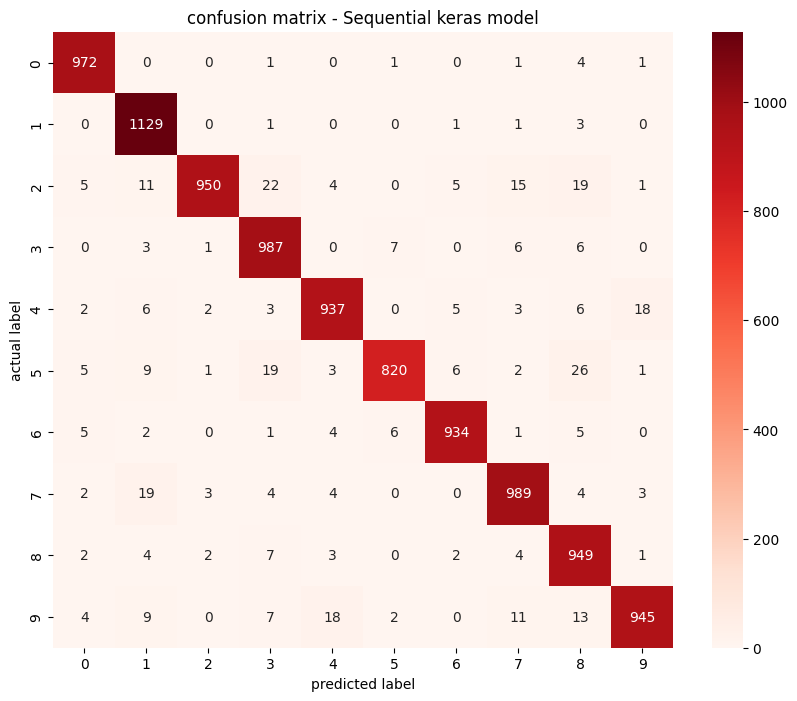

In [9]:
confusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Reds')
plt.title('confusion matrix - Sequential keras model')
plt.xlabel('predicted label')
plt.ylabel('actual label')
plt.savefig('./figures/keras_sequential_confusion_matrix.png')
plt.show()

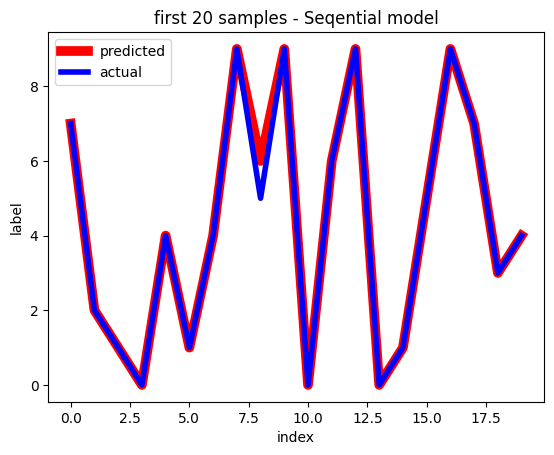

In [10]:
plt.plot(y_pred[:20], 'red', label='predicted', linewidth=7)
plt.plot(y_test[:20], 'blue', label='actual', linewidth=4)
plt.title('first 20 samples - Seqential model')
plt.xlabel('index')
plt.ylabel('label')
plt.legend()
plt.savefig('./figures/keras_sequential_pred_vs_actual.png')
plt.show()

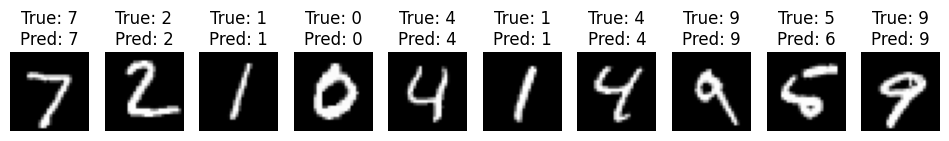

In [12]:
def sample_pred(images, true_labels, pred_labels, n=10):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}")
        plt.axis('off')
    plt.savefig('./figures/keras_sequential_sample_pred_visualisation.png')
    plt.show()
    
sample_pred(x_test, y_test, y_pred)

4721


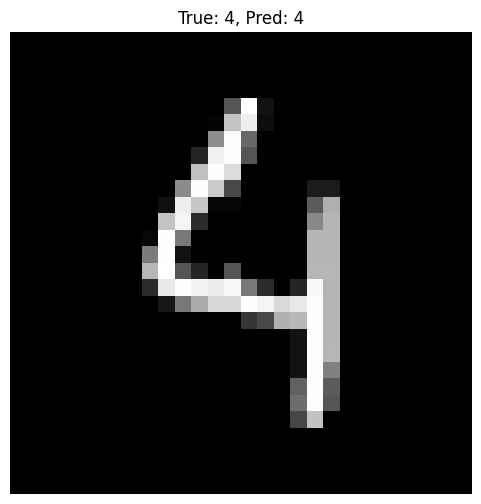

In [13]:
target = np.random.choice(len(x_test), 1, replace=False)
print(target[0])

plt.figure(figsize=(6, 6))
plt.imshow(x_test[target[0]], cmap="gray")
plt.title(f"True: {y_test[target[0]]}, Pred: {y_pred[target[0]]}")
plt.axis('off')
plt.show()